In [1]:
# Import our tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target

# Preview the data
df.head()



Matplotlib is building the font cache; this may take a moment.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Diagnosis counts:
diagnosis
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


/var/folders/3j/4slf614x4n319r3fd7057nq00000gn/T/ipykernel_7111/3712146406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='coolwarm')


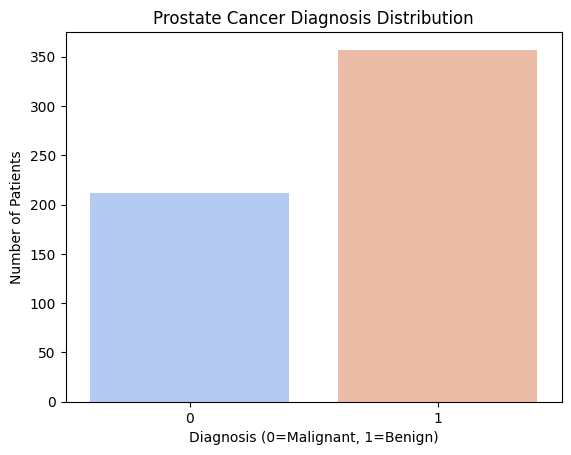

In [2]:
# How many malignant vs benign cases?
print("Diagnosis counts:")
print(df['diagnosis'].value_counts())
print()
print("0 = Malignant, 1 = Benign")

# Visualize it
sns.countplot(x='diagnosis', data=df, palette='coolwarm')
plt.title('Prostate Cancer Diagnosis Distribution')
plt.xlabel('Diagnosis (0=Malignant, 1=Benign)')
plt.ylabel('Number of Patients')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# Separate features (X) from diagnosis label (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 455
Testing samples:  114


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Build the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it
model.fit(X_train, y_train)

# Test it on unseen patients
y_pred = model.predict(X_test)

# How accurate is it?
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 96.49%


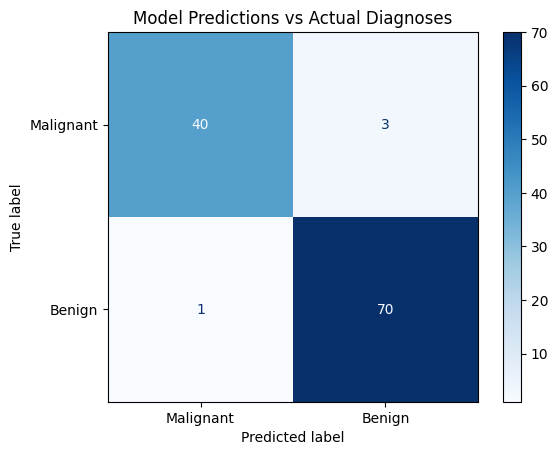

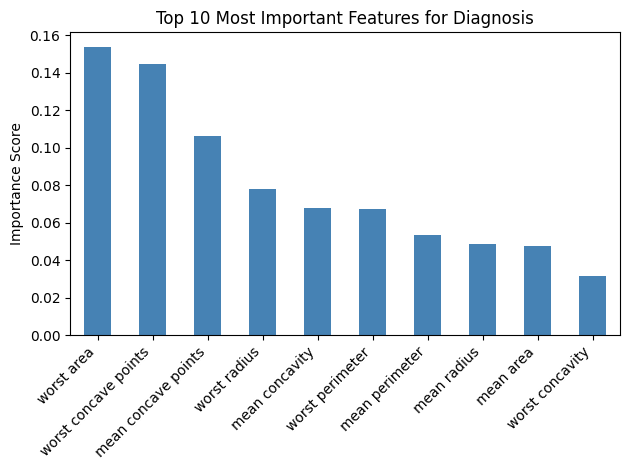

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Model Predictions vs Actual Diagnoses')
plt.show()

# Which features mattered most?
feature_importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

feature_importance.plot(kind='bar', color='steelblue')
plt.title('Top 10 Most Important Features for Diagnosis')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()